# EuroSat Image Classification using Vision Transformer (ViT)

Hector Becerra  
Juan Terven  
2023

The **Vision Transformer (ViT)** is a pioneering neural network architecture...

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
import numpy as np 
import torch
import torchvision.transforms as transforms
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import wandb
from torch.utils.data import DataLoader
import json
from torchvision.models import vit_l_32,ViT_L_32_Weights
from torchvision.models import vit_b_32, vit_l_32, ViT_B_32_Weights, ViT_L_32_Weights

from train_utils import get_predictions,compute_val_loss,EarlyStopping,train_model
from eval_utils import remove_wandb_hooks,evaluate_test_set,precision_recall_analysis
# 确保您已经按照新脚本的指示更新了 EuroSAT.py 文件
from EuroSAT import EurosatDataset,visualize_classes

## Login to Wandb to log experiment

In [2]:
os.environ['WANDB_NOTEBOOK_NAME'] = 'EuroSat_ViT_Classifier.ipynb'

wandb.login()

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find EuroSat_ViT_Classifier.ipynb.
wandb: Currently logged in as: wuwanxing3574 (wuwanxing3574-institut-polytechnique-de-paris) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data
The [EuroSat Dataset]...

### **--- 代码修改区域 1: 更新数据路径 ---**
根据您的 `data_preprocessing_new.ipynb` 脚本，我们将路径分为 `data_path`（指向图片文件夹）和 `metadata_path`（指向包含CSV和JSON文件的文件夹）。

In [3]:
# 图片所在的根文件夹
# 注意：根据您的新脚本，这里应该指向 EuroSAT_RGB 文件夹
data_path = "/data1/wwx/EuroSat_classification/dataset/EuroSAT_RGB"

# CSV和JSON文件所在的文件夹
# 这是由您的预处理脚本生成的
metadata_path = "/data1/wwx/EuroSat_classification/dataset/split_info"

### **--- 代码修改区域 2: 更新标签映射文件的加载路径 ---**

In [4]:
# Load the labels from the new metadata_path
with open(os.path.join(metadata_path, "label_map.json"), "r") as f:
    label_to_index = json.load(f)

In [5]:
index_to_label = {v: k for k, v in label_to_index.items()}
print(index_to_label)

{0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


## Data Transformations

In [6]:
# Check the transformations used in the pre-trained model
weights = ViT_L_32_Weights.DEFAULT
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [7]:
# Define a sequence of transformations to be applied to images
transformToTensor = transforms.Compose([
    transforms.Resize((256,)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### **--- 代码修改区域 3: 更新数据集的创建方式 ---**
现在我们使用 `csv_path` 参数来指定 `train.csv`, `valid.csv` 和 `test.csv` 的位置，而不是使用 `_type`。

In [8]:
# Create dataset instances
# Instantiate the EurosatDataset class using the new csv_path argument.
train_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'train.csv'),
    transform=transformToTensor,
    data_path=data_path
)

valid_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'valid.csv'),
    transform=transformToTensor,
    data_path=data_path
)

test_dataset = EurosatDataset(
    csv_path=os.path.join(metadata_path, 'test.csv'),
    transform=transformToTensor,
    data_path=data_path
)

# Define batch sizes for training and validation data.
train_batch = 1024
val_batch = 1024 

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=val_batch, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4500387..1.6988237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..-0.47982562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2959158..0.5833553].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..-0.09638336].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..-0.16610013].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.33016

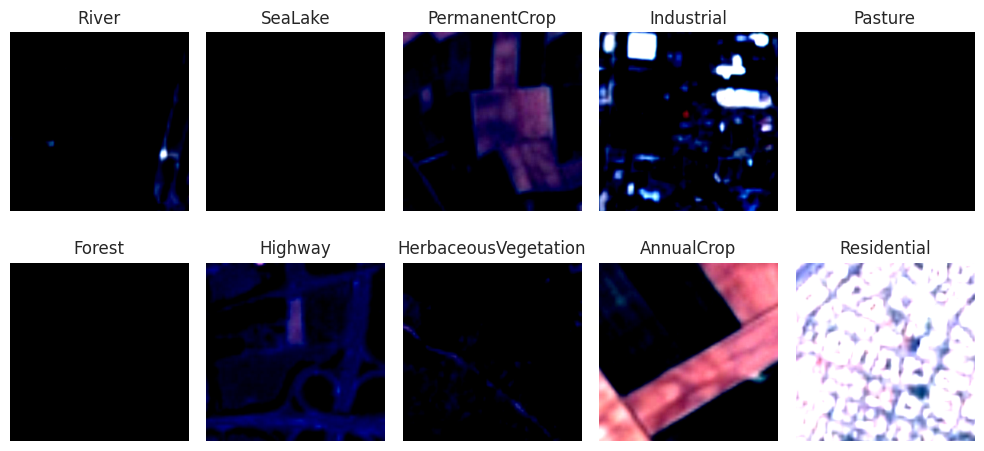

In [9]:
visualize_classes(train_loader, index_to_label)

In [10]:
dataset_managers = {
    'valid': valid_loader,
    'train': train_loader,
    'test': test_loader
}

print(f"Train set batches: {len(train_loader)}")
print(f"Validation set batches: {len(valid_loader)}")
print(f"Test set examples: {len(test_dataset)}")

Train set batches: 19
Validation set batches: 4
Test set examples: 4050


## Labels distribution

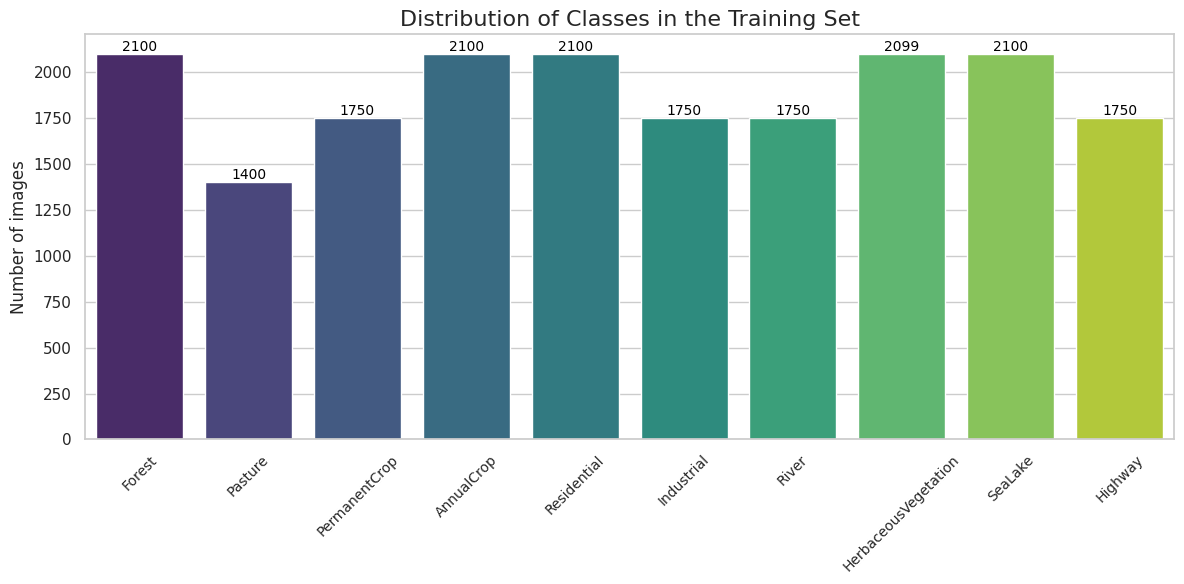

In [11]:
# Make sure to use the .data attribute from your updated EurosatDataset class
labels = train_dataset.data['Label'].values

# Convert numerical labels to string names
label_names = [index_to_label[label] for label in labels]

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.countplot(x=label_names, hue=label_names, palette="viridis", legend=False)

plt.ylabel('Number of images', fontsize=12)
plt.title('Distribution of Classes in the Training Set', fontsize=16)
plt.xticks(rotation=45, fontsize=10)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Model

In [12]:
# Use un-pretrained model
model = vit_l_32()

# Replace the model head with the number of classes
num_classes = 10
model.heads.head = nn.Linear(1024, num_classes) 
model = model.cuda() 
# model.to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU")
    model = nn.DataParallel(model)

# # 使用更小的 vit_b_32 (基础版) 模型，而不是 vit_l_32 (大型版)
# model = vit_b_32()

# # Replace the model head with the number of classes
# num_classes = 10
# # 注意：基础版(Base)的 head 输入维度是 768，不是大型版(Large)的 1024
# model.heads.head = nn.Linear(768, num_classes) 
# model.to(DEVICE)

使用 4 个GPU


# Training model from Scratch

In [12]:
project_name = "EuroSAT"
model_name = "ViT32"
models_path = "./models/" # 建议使用相对路径

# #add by wky
# project_name = "EuroSAT"
# model_name = "ViT32-Base-Scratch" # 增加了 "-Base-Scratch" 以表明是基础版且从零开始
# models_path = "./models/" # 保持相对路径

In [14]:
epochs = 20
lr = 0.0001
patience = 10

run = wandb.init(
    project=project_name,
    name=model_name,
    notes="ViT32 from scratch",
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })



loss_i, loss_val_i = train_model(model=model, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience, 
                                 model_name=model_name)

Starting training with early stopping patience of 10
Each epoch has 19 steps.

Epoch: 1...
Validation Loss: 1.7989 Accuracy: 0.3439
Best model saved.
Epoch duration: 64.38s

Epoch: 2...
Validation Loss: 1.4977 Accuracy: 0.4234
Best model saved.
Epoch duration: 62.26s

Epoch: 3...
Validation Loss: 1.3079 Accuracy: 0.5142
Best model saved.
Epoch duration: 60.40s

Epoch: 4...
Validation Loss: 1.2711 Accuracy: 0.5251
Best model saved.
Epoch duration: 61.15s

Epoch: 5...
Validation Loss: 0.9932 Accuracy: 0.6149
Best model saved.
Epoch duration: 60.69s

Epoch: 6...
Validation Loss: 0.9052 Accuracy: 0.6517
Best model saved.
Epoch duration: 62.01s

Epoch: 7...
Validation Loss: 0.8397 Accuracy: 0.7102
Best model saved.
Epoch duration: 62.63s

Epoch: 8...
Validation Loss: 0.6139 Accuracy: 0.7847
Best model saved.
Epoch duration: 61.26s

Epoch: 9...
Validation Loss: 0.6028 Accuracy: 0.7875
Best model saved.
Epoch duration: 61.39s

Epoch: 10...
Validation Loss: 0.5535 Accuracy: 0.8000
Best model s

## Save model

In [15]:
os.makedirs(models_path, exist_ok=True)
model_save_path = os.path.join(models_path, model_name + ".pth")
print(f"Saving model to: {model_save_path}")
torch.save(obj=model.state_dict(), f=model_save_path)

Saving model to: ./models/ViT32.pth


In [16]:
with open(f"{models_path}/loss_{model_name}.txt", "w") as file:
    file.write(f"loss_i: {loss_i}\n")
    file.write(f"loss_val_i: {loss_val_i}\n")

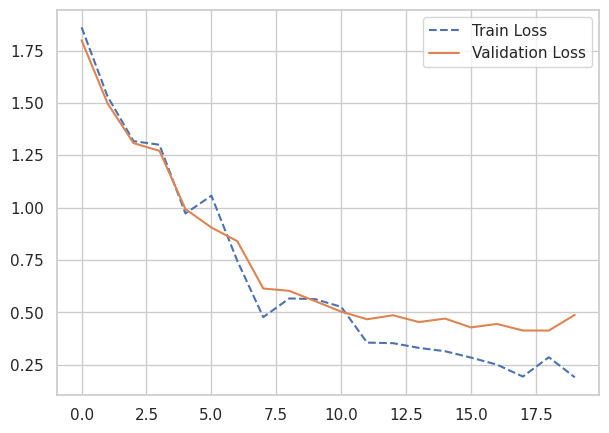

In [17]:
plt.figure(figsize=(7,5))
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

In [18]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [19]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)

model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model.load_state_dict(torch.load(f = model_save_path))

Loading model ./models/ViT32.pth


<All keys matched successfully>

In [20]:
DEVICE = torch.device('cuda') 
evaluate_test_set(model, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.805     0.924     0.860       450
              Forest      0.849     0.984     0.912       450
HerbaceousVegetation      0.804     0.900     0.849       450
             Highway      0.822     0.763     0.791       375
          Industrial      0.923     0.893     0.908       375
             Pasture      0.819     0.830     0.825       300
       PermanentCrop      0.865     0.616     0.720       375
         Residential      0.836     0.960     0.893       450
               River      0.909     0.744     0.818       375
             SeaLake      0.978     0.871     0.921       450

            accuracy                          0.856      4050
           macro avg      0.861     0.849     0.850      4050
        weighted avg      0.861     0.856     0.854      4050



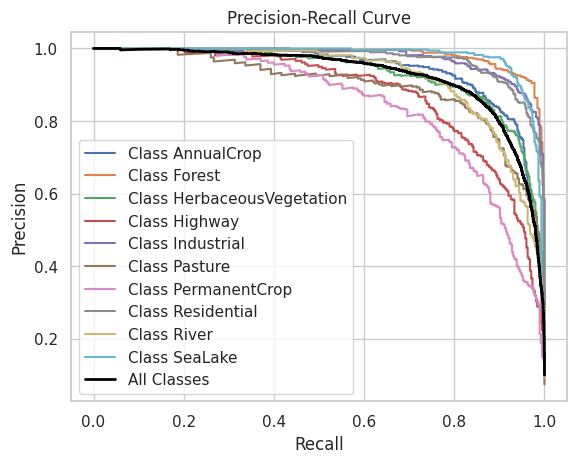

In [21]:
precision_recall_analysis(model, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [22]:
wandb.finish()

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
val_accuracy,▁▂▃▃▅▅▆▇▇▇▇▇▇███████
val_loss,█▆▆▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch,19
val_accuracy,0.84819
val_loss,0.48814


## Load the precision/recall curve and plot it

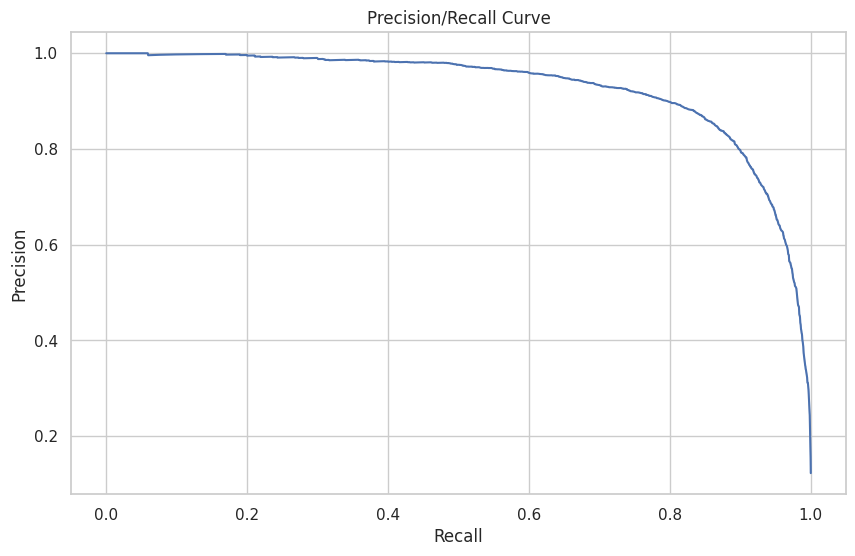

In [13]:
filename = f"{model_name}_precision_recall_values.json"
file_path = os.path.join(models_path, filename)

with open(file_path, 'r') as file:
    precision_recall_data = json.load(file)
    
all_classes_data = precision_recall_data['All Classes']

# Extract precision and recall values
precisions = all_classes_data.get('precision', [])
recalls = all_classes_data.get('recall', [])

# Create a DataFrame for plotting
df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls
})

# Plotting the precision/recall curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Recall', y='Precision')
plt.title('Precision/Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

## Clean-up

In [ ]:
import gc

del model
torch.cuda.empty_cache()
gc.collect()


# Now train the model with pre-trained weights

In [14]:
# Use pretrained model
model2 = vit_l_32(weights=ViT_L_32_Weights.IMAGENET1K_V1)
model2 = model2.cuda()
# Replace the model head with the number of classes
num_classes = 10
model2.heads.head = nn.Linear(1024, num_classes) 
model2 = model2.cuda()
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU")
    model2 = nn.DataParallel(model2)

使用 4 个GPU


## Train with pre-trained weights

In [15]:
model_name = "ViT32-Pretrained"

In [16]:
epochs = 3
lr = 0.0001
patience = 3

run = wandb.init(
    # Set the project where this run will be logged
    project=project_name,
    name=model_name,
    notes="ViT32 pre-trained on ImageNet",
    # Track hyperparameters and run metadata
    config={
        "learning_rate": lr,
        "epochs": epochs,
        "batch_size": train_batch,
        "patience": patience
    })

loss_i, loss_val_i = train_model(model=model2, epochs=epochs, 
                                 train_loader=train_loader,
                                 valid_loader=valid_loader,
                                 lr=lr, patience=patience,
                                 model_name=model_name)

Starting training with early stopping patience of 3
Each epoch has 19 steps.

Epoch: 1...
Validation Loss: 0.1183 Accuracy: 0.9630
Best model saved.
Epoch duration: 67.67s

Epoch: 2...
Validation Loss: 0.0760 Accuracy: 0.9753
Best model saved.
Epoch duration: 64.29s

Epoch: 3...
Validation Loss: 0.0719 Accuracy: 0.9780
Best model saved.
Epoch duration: 63.43s
Last model saved.


## Save model

In [17]:
# Create models directory
os.makedirs(models_path, exist_ok=True)

# 2. Create model save path
model_save_path = os.path.join(models_path, model_name + ".pth")

# 3. Save the model state dict
print(f"Saving model to: {model_save_path}")
torch.save(obj=model2.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path)

Saving model to: ./models/ViT32-Pretrained.pth


In [18]:
# Save the loss data in a file
with open(f"{models_path}/loss_{model_name}.txt", "w") as archivo:
    archivo.write(f"loss_i: {loss_i}\n")
    archivo.write(f"loss_val_i: {loss_val_i}\n")

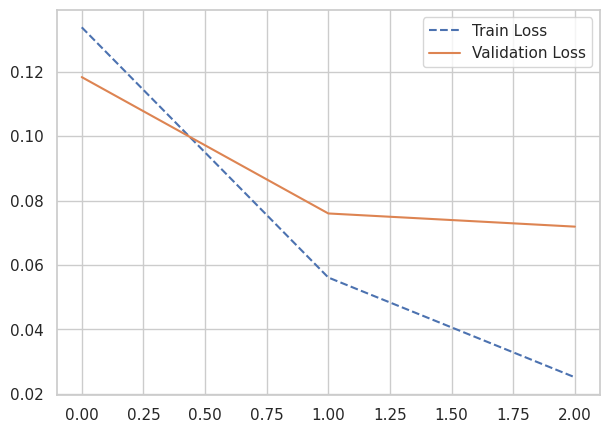

In [19]:
plt.figure(figsize=(7,5))
# Use a dashed line for the training loss, and add markers
plt.plot(loss_i, label="Train Loss", linestyle='--', alpha=1.0)

# Use a solid line for the validation loss
plt.plot(loss_val_i, label="Validation Loss", linestyle='-', alpha=1.0)
plt.legend()
plt.show()

# Evaluate model

In [ ]:
# Call this function before evaluating your model to remove any wandb hook
#remove_wandb_hooks(model)

## Load trained model

In [20]:
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
model_save_path = models_path + f"{model_name}.pth"
print(f"Loading model {model_save_path}")
model2.load_state_dict(torch.load(f = model_save_path))
DEVICE = torch.device('cuda')

Loading model ./models/ViT32-Pretrained.pth


In [21]:
evaluate_test_set(model2, test_loader, DEVICE, index_to_label=index_to_label)

                      precision    recall  f1-score   support

          AnnualCrop      0.973     0.947     0.959       450
              Forest      0.974     0.998     0.986       450
HerbaceousVegetation      0.979     0.956     0.967       450
             Highway      0.987     0.984     0.985       375
          Industrial      0.982     0.995     0.988       375
             Pasture      0.952     0.983     0.967       300
       PermanentCrop      0.942     0.955     0.948       375
         Residential      0.996     0.991     0.993       450
               River      0.992     0.987     0.989       375
             SeaLake      0.998     0.991     0.994       450

            accuracy                          0.978      4050
           macro avg      0.977     0.979     0.978      4050
        weighted avg      0.978     0.978     0.978      4050



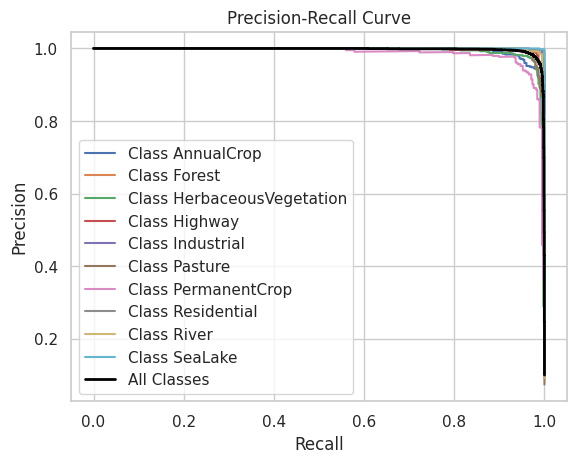

In [22]:
precision_recall_analysis(model2, test_loader, DEVICE,
                          output_path=models_path,
                          model_name=model_name,
                          index_to_label=index_to_label)

In [ ]:
wandb.finish()

epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▇▅▄▃▂▄▄▃▂▂▂▃▂▂▂▂▂▁▂▂▂▂▂▂▁▂▁▂▂▂▁▂▂▁▂▂▁▂▁
val_accuracy,▄▇▅█▁█▇█▅▇▇▅▁▇▇█
val_loss,▃▁▃▂▆▁▂▁▄▃▁▄█▃▂▂
epoch,15
step,9445
train_loss,0.00682
val_accuracy,0.965
val_loss,0.13027


In [ ]:
del model2
torch.cuda.empty_cache()
gc.collect()

18